# Texas Lotto Statistical Analysis and Predictive Modeling

## Jose Reyes  
MS Business Analytics & Artificial Intelligence  
University of Texas Rio Grande Valley

This project analyzes historical Texas Lotto winning numbers using exploratory data analysis, inferential statistics, Monte Carlo simulation, and machine learning techniques to evaluate statistical behavior and predictive structure within lottery draw data.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools

from collections import Counter

from scipy.stats import chisquare

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Dataset Loading and Preparation

The historical Texas Lotto dataset was imported into Google Colab and cleaned for analysis. Only the six winning number columns were retained for statistical analysis and predictive modeling.

In [24]:
df = pd.read_csv('lottotexas.csv')

In [25]:
df.head()

,Game,Month,Day,Year,Number,Number.1,Number.2,Number.3,Number.4,Number.5
0,Lotto Texas,11,14,1992,13,16,22,29,32,36
1,Lotto Texas,11,18,1992,27,31,39,44,45,47
2,Lotto Texas,11,21,1992,11,21,24,28,31,46
3,Lotto Texas,11,25,1992,14,21,36,39,40,42
4,Lotto Texas,11,28,1992,9,17,21,24,28,50


# Data Cleaning

The dataset was cleaned by retaining only the six winning lotto number columns and converting all values into integer format for statistical processing.

In [26]:
print(df.columns)

Index(['Game', 'Month', 'Day', 'Year', 'Number', 'Number.1', 'Number.2',
       'Number.3', 'Number.4', 'Number.5'],
      dtype='object')


In [27]:
lotto_cols = [
    "Number",
    "Number.1",
    "Number.2",
    "Number.3",
    "Number.4",
    "Number.5"
]

In [28]:
df[lotto_cols].head()

,Number,Number.1,Number.2,Number.3,Number.4,Number.5
0,13,16,22,29,32,36
1,27,31,39,44,45,47
2,11,21,24,28,31,46
3,14,21,36,39,40,42
4,9,17,21,24,28,50


In [29]:
all_numbers = []

for col in lotto_cols:
  all_numbers.extend(df[col].tolist())

In [30]:
print(all_numbers[:30])

[13, 27, 11, 14, 9, 5, 7, 4, 18, 14, 9, 9, 5, 3, 5, 8, 2, 5, 3, 3, 1, 4, 4, 11, 3, 23, 6, 5, 3, 18]


# Exploratory Data Analysis

Exploratory data analysis was conducted to identify structural patterns, probability behavior, and frequency distributions within historical Texas Lotto draws.

## Number Frequency Analysis

This section evaluates how frequently each lotto number appeared across historical draws.

In [31]:
number_counts = Counter(all_numbers)

In [32]:
freq_df = pd.DataFrame(
    number_counts.items(),
    columns=["Number", "Frequency"]
)

In [33]:
freq_df = freq_df.sort_values(
    by="Frequency",
    ascending=False
)
freq_df.head(10)

,Number,Frequency
37,26,474
7,4,465
17,15,461
20,31,459
1,27,456
10,8,456
47,19,456
15,10,452
18,39,450
45,21,446


In [34]:
freq_df.tail(10)

,Number,Frequency
13,23,397
24,47,364
43,46,362
35,48,360
19,45,359
49,50,359
51,52,303
50,54,295
53,51,281
52,53,270


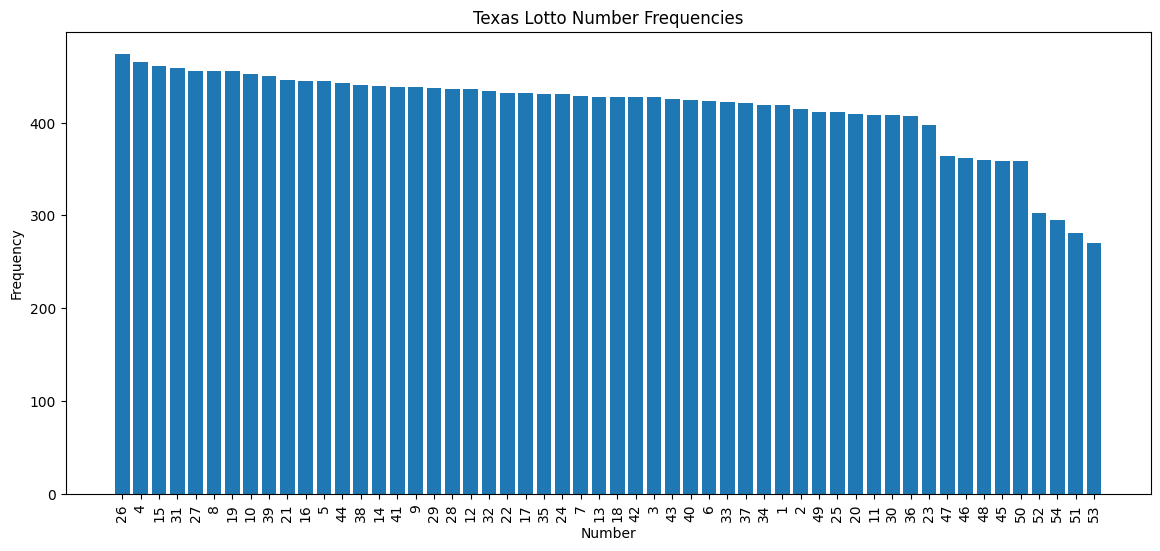

In [35]:
plt.figure(figsize=(14,6))

plt.bar(
    freq_df["Number"].astype(str),
    freq_df["Frequency"]
)

plt.title("Texas Lotto Number Frequencies")
plt.xlabel("Number")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

### Interpretation

The historical number frequency distribution appears relatively balanced overall, although moderate variation exists across individual numbers. This suggests that while some numbers appeared more frequently over time, the overall distribution remained broadly consistent with expected random fluctuation behavior.

## Odd and Even Pattern Analysis

This section evaluates the structural distribution of odd and even numbers within historical draws.

## Odd and Even Pattern Analysis

This section evaluates the structural distribution of odd and even numbers within historical draws.

In [36]:
odd_even_patterns = []

for index, row in df[lotto_cols].iterrows():

  odd_count = sum(num % 2 != 0 for num in row)

  even_count = 6 - odd_count

  pattern = f"{odd_count} Odd / {even_count} Even"

  odd_even_patterns.append(pattern)

In [37]:
pattern_counts = pd.Series(
    odd_even_patterns
).value_counts(
)

pattern_counts

,count
3 Odd / 3 Even,1266
4 Odd / 2 Even,906
2 Odd / 4 Even,895
5 Odd / 1 Even,299
1 Odd / 5 Even,299
0 Odd / 6 Even,40
6 Odd / 0 Even,36


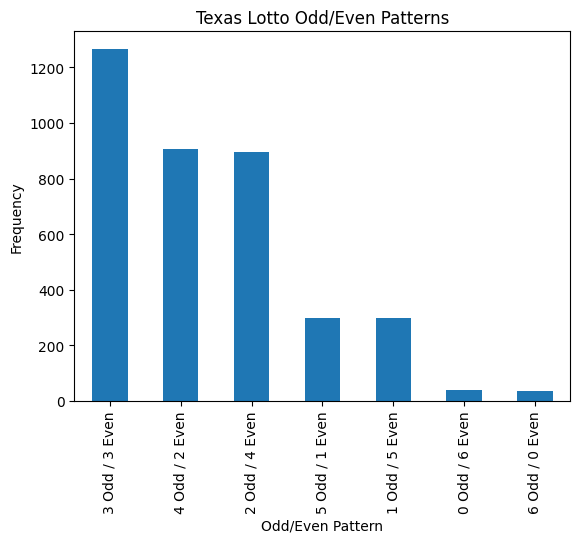

In [38]:
pattern_counts.plot(kind="bar")

plt.title("Texas Lotto Odd/Even Patterns")
plt.xlabel("Odd/Even Pattern")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Balanced odd/even combinations occurred substantially more frequently than extreme patterns such as all odd or all even draws.

## High and Low Number Analysis

This section evaluates the distribution of lower and higher lotto numbers across historical draws.

In [39]:
high_low_patterns = []

for index, row in df[lotto_cols].iterrows():

  low_count = sum(num <= 27 for num in row)

  high_count = 6 - low_count

  pattern = f"{low_count} Low / {high_count} High"

  high_low_patterns.append(pattern)

In [40]:
high_low_counts = pd.Series(
    high_low_patterns
).value_counts()

high_low_counts

,count
3 Low / 3 High,1263
4 Low / 2 High,950
2 Low / 4 High,792
5 Low / 1 High,398
1 Low / 5 High,242
6 Low / 0 High,59
0 Low / 6 High,37


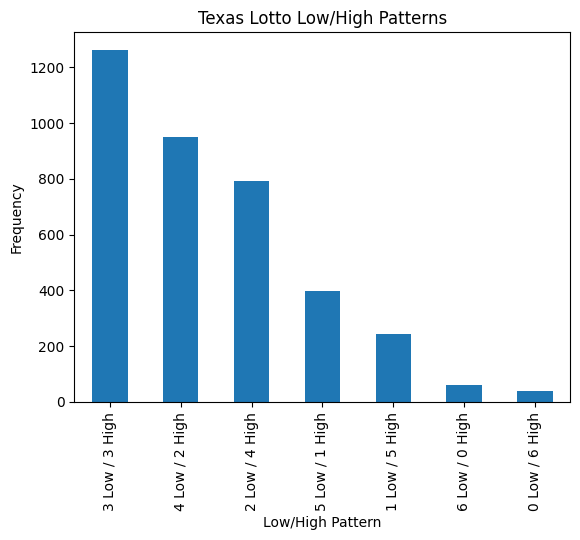

In [41]:
high_low_counts.plot(kind="bar")

plt.title("Texas Lotto Low/High Patterns")
plt.xlabel("Low/High Pattern")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Balanced high/low distributions occurred substantially more frequently than heavily skewed combinations.

## Consecutive Number Analysis

This section evaluates how frequently consecutive numbers appeared together within historical draws.

In [42]:
consecutive_counts = []

for index, row in df[lotto_cols].iterrows():

  sorted_nums = sorted([int(x) for x in row.tolist()])

  consecutive = 0

  for i in range(len(sorted_nums)-1):

    if sorted_nums[i+1] - sorted_nums[i] == 1:
      consecutive += 1

  consecutive_counts.append(consecutive)

In [43]:
consecutive_summary = pd.Series(
    consecutive_counts
).value_counts()

consecutive_summary

,count
0,1994
1,1416
2,300
3,29
4,2


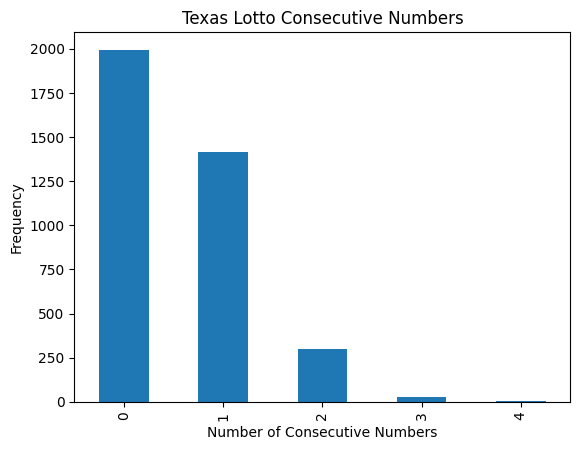

In [44]:
consecutive_summary.plot(kind="bar")

plt.title("Texas Lotto Consecutive Numbers")
plt.xlabel("Number of Consecutive Numbers")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Most historical draws contained either zero or one consecutive number pairing, although larger consecutive groupings still occurred periodically.

## Draw Sum Distribution Analysis

This section evaluates the total sum distribution of historical lotto draws.

In [45]:
draw_sums = []

for index, row in df[lotto_cols].iterrows():

  nums = [int(x) for x in row.tolist()]

  total = sum(row)

  draw_sums.append(total)

  if index < 10:

    print(f"Draw {index+1}: {nums} = {total}")



Draw 1: [13, 16, 22, 29, 32, 36] = 148
Draw 2: [27, 31, 39, 44, 45, 47] = 233
Draw 3: [11, 21, 24, 28, 31, 46] = 161
Draw 4: [14, 21, 36, 39, 40, 42] = 192
Draw 5: [9, 17, 21, 24, 28, 50] = 149
Draw 6: [5, 17, 19, 25, 26, 38] = 130
Draw 7: [7, 23, 24, 35, 36, 45] = 170
Draw 8: [4, 11, 16, 31, 32, 45] = 139
Draw 9: [18, 23, 25, 26, 38, 42] = 172
Draw 10: [14, 23, 24, 31, 38, 42] = 172


In [46]:
sum_series =pd.Series(draw_sums)

sum_series.describe()

,0
count,3741.000000
mean,158.830794
std,36.026141
min,47.000000
25%,134.000000
50%,158.000000
75%,182.000000
max,279.000000


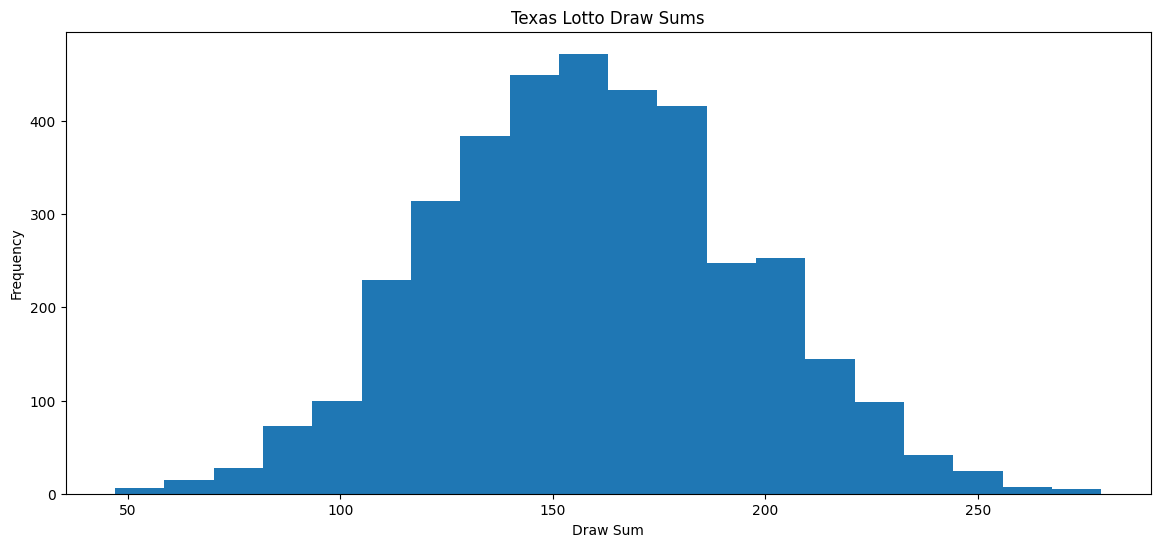

In [47]:
plt.figure(figsize=(14,6))

plt.hist(
    sum_series,
    bins=20
)

plt.title("Texas Lotto Draw Sums")
plt.xlabel("Draw Sum")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Historical draw sums followed an approximately normal distribution centered around mid-range totals.

## Pair Frequency Heatmap Analysis

This section evaluates historical co-occurrence relationships between lotto number pairs.

In [48]:
pair_counts = Counter()

In [49]:
for index, row in df[lotto_cols].iterrows():

  nums = sorted([int(x) for x in row.tolist()])

  pairs = itertools.combinations(nums, 2)

  pair_counts.update(pairs)

pair_counts.most_common(10)

[((14, 26), 71),
 ((8, 26), 69),
 ((21, 28), 60),
 ((20, 41), 59),
 ((8, 15), 59),
 ((21, 27), 59),
 ((19, 39), 59),
 ((22, 29), 58),
 ((15, 37), 58),
 ((20, 29), 58)]

In [50]:
matrix = np.zeros((55,55))

for (num1, num2), count in pair_counts.items():

  matrix[num1][num2] = count

  matrix[num2][num1] = count

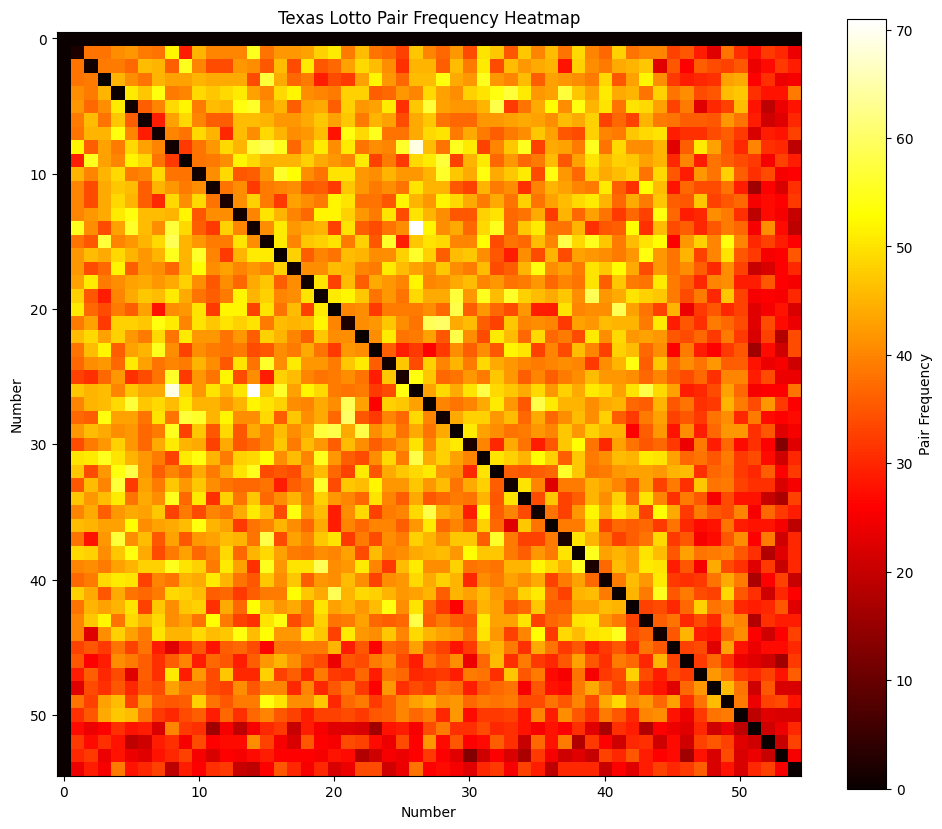

In [51]:
plt.figure(figsize=(12,10))

plt.imshow(matrix, cmap='hot', interpolation='nearest')

plt.colorbar(label="Pair Frequency")

plt.title("Texas Lotto Pair Frequency Heatmap")

plt.xlabel("Number")

plt.ylabel("Number")

plt.show()

### Interpretation

The pair frequency heatmap demonstrates moderate variation in historical co-occurrence frequencies, although no deterministic pair structures emerged.

# Inferential Statistical Analysis

A chi-square goodness-of-fit test was performed to evaluate whether historical lotto number frequencies followed a perfectly uniform distribution.

In [52]:
observed = freq_df["Frequency"]

In [53]:
expected = [observed.mean()] * len(observed)

In [54]:
chi2, p = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("Chi-Square Statistic:", chi2)

print("P-Value:", p)

Chi-Square Statistic: 261.59903769045707
P-Value: 2.3179692937085106e-29


### Interpretation

The resulting p-value fell below the 0.05 significance threshold, indicating statistically significant deviations from perfect uniformity.

Although some lotto numbers appeared more frequently than others across historical draws, the overall behavior remained broadly consistent with expected random variation within a large sample size.

# Monte Carlo Simulation

Monte Carlo simulation was used to generate simulated lottery draws for comparison against historical distributions.

In [55]:
simulated_draws = []

for _ in range(10000):

  simulated_draw = random.sample(range(1, 46), 6)

  simulated_draws.append(simulated_draw)

In [56]:
simulated_draws[:5]

[[13, 1, 2, 35, 28, 22],
 [10, 22, 2, 40, 31, 33],
 [24, 3, 22, 25, 34, 15],
 [24, 1, 29, 16, 37, 34],
 [37, 26, 1, 25, 5, 41]]

In [57]:
sim_sums = []

for draw in simulated_draws:

  total = sum(draw)

  sim_sums.append(total)

In [58]:
sim_sums_series = pd.Series(sim_sums)

sim_sums_series.describe()

,0
count,10000.000000
mean,138.394600
std,29.666481
min,27.000000
25%,118.000000
50%,138.000000
75%,159.000000
max,238.000000


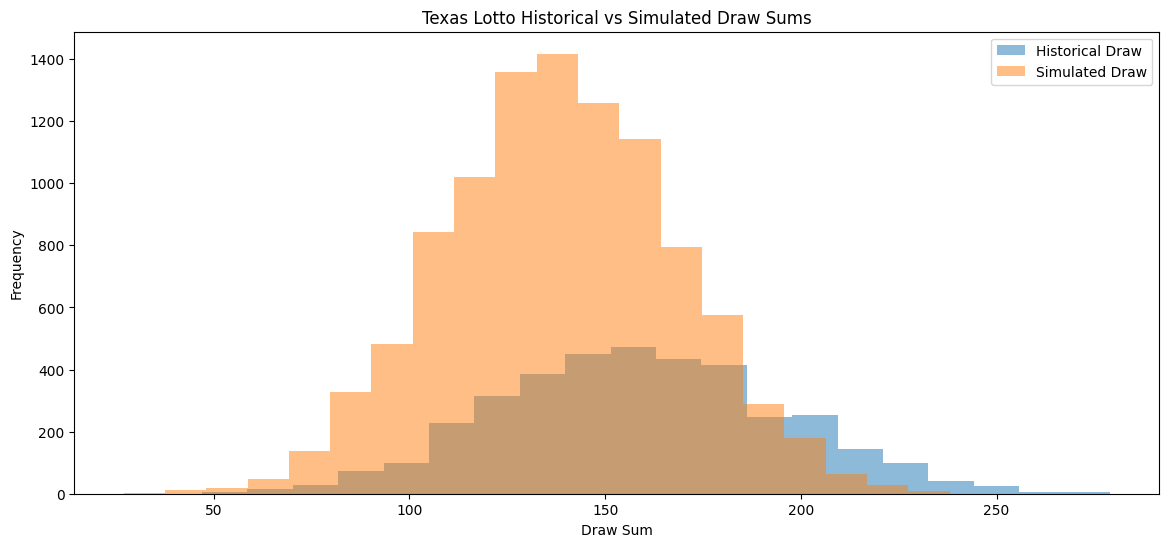

In [59]:
plt.figure(figsize=(14,6))

plt.hist(
    sum_series,
    bins=20,
    alpha=0.5,
    label="Historical Draw")

plt.hist(
    sim_sums_series,
    bins=20,
    alpha=0.5,
    label="Simulated Draw"
)

plt.title("Texas Lotto Historical vs Simulated Draw Sums")
plt.xlabel("Draw Sum")
plt.ylabel("Frequency")

plt.legend()

plt.show()

### Interpretation

Simulated draw distributions closely resembled historical lotto distributions, supporting expected random probability behavior.

# Rule-Based Balanced Ticket Generator

A constrained simulation model was developed to generate statistically balanced lotto tickets using historically common structural characteristics.

In [60]:
def generate_balanced_ticket():

    while True:

        ticket = sorted(random.sample(range(1,55), 6))

        odd_count = sum(num % 2 != 0 for num in ticket)

        high_count = sum(num > 27 for num in ticket)

        total = sum(ticket)

        consecutive = sum(
            ticket[i+1] - ticket[i] == 1
            for i in range(5)
        )

        if (
            2 <= odd_count <= 4 and
            2 <= high_count <= 4 and
            130 <= total <= 190 and
            consecutive <= 2
        ):

            return ticket

In [61]:
for i in range(10):

    print(
        f"Balanced Ticket {i+1}:",
        generate_balanced_ticket()
    )

Balanced Ticket 1: [7, 19, 22, 23, 28, 43]
Balanced Ticket 2: [20, 22, 24, 30, 41, 49]
Balanced Ticket 3: [4, 9, 24, 25, 38, 49]
Balanced Ticket 4: [1, 8, 16, 31, 35, 42]
Balanced Ticket 5: [8, 14, 25, 30, 45, 53]
Balanced Ticket 6: [2, 17, 19, 31, 32, 35]
Balanced Ticket 7: [3, 23, 24, 40, 45, 53]
Balanced Ticket 8: [6, 17, 32, 34, 45, 47]
Balanced Ticket 9: [9, 23, 30, 37, 39, 52]
Balanced Ticket 10: [6, 17, 22, 31, 38, 54]


### Interpretation

Generated tickets reflected historically common structural characteristics including balanced odd/even distributions, balanced high/low compositions, and moderate draw sums.

# Machine Learning Modeling

A Random Forest classification model was developed to evaluate whether engineered structural features could predict broader draw characteristics.

## Feature Engineering

Structural features including odd counts, high-number counts, and consecutive pair counts were engineered for machine learning analysis.

In [62]:
ml_df = pd.DataFrame()

ml_df["Draw_Sum"] = draw_sums

ml_df["Odd_Count"] = [
    sum(num % 2 != 0 for num in row)
    for _, row in df[lotto_cols].iterrows()
]

ml_df["High_Count"] = [
    sum(num > 27 for num in row)
    for _, row in df[lotto_cols].iterrows()
]

ml_df["Consecutive_Count"] = consecutive_counts

## Target Variable Creation

A binary target variable was created to classify whether historical draw sums fell above or below the dataset median threshold.

In [63]:
median_sum = ml_df["Draw_Sum"].median()

ml_df["High_Sum_Target"] = (
    ml_df["Draw_Sum"] > median_sum
).astype(int)

ml_df.head()

,Draw_Sum,Odd_Count,High_Count,Consecutive_Count,High_Sum_Target
0,148,2,3,0,0
1,233,5,5,1,1
2,161,3,3,0,1
3,192,2,4,1,1
4,149,3,2,0,0


### Interpretation

The target variable transformed the project into a supervised machine learning classification problem by categorizing historical draws into higher-sum and lower-sum groups based on the historical median draw sum.

## Train-Test Split

The dataset was divided into training and testing subsets using stratified sampling.

In [64]:
X = ml_df.drop(
    columns=["Draw_Sum", "High_Sum_Target"]
)

y = ml_df["High_Sum_Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Random Forest Classification Model

A Random Forest classifier was trained to evaluate predictive relationships between engineered features and draw sum classifications.

In [65]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [66]:
rf_predictions = rf_model.predict(X_test)

In [67]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.92      0.73      0.82       375
           1       0.78      0.94      0.85       374

    accuracy                           0.83       749
   macro avg       0.85      0.83      0.83       749
weighted avg       0.85      0.83      0.83       749



### Interpretation

The Random Forest model achieved approximately 83% classification accuracy when predicting broader draw sum classifications.

## Feature Importance Analysis

Feature importance analysis was conducted to evaluate which engineered variables contributed most strongly to model predictions.

In [68]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

In [69]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,High_Count,0.967994
0,Odd_Count,0.017928
2,Consecutive_Count,0.014078


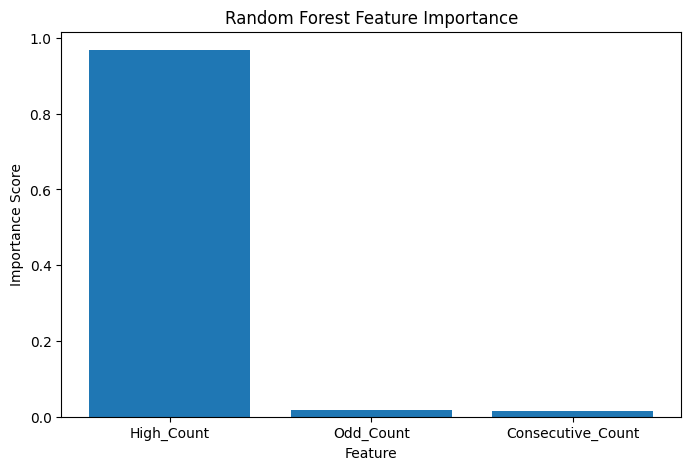

In [70]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Feature")

plt.ylabel("Importance Score")

plt.show()

### Interpretation

High_Count was identified as the dominant predictive variable within the classification model.

# Conclusions

This project demonstrated that while exact lottery outcomes remain fundamentally unpredictable, broader structural characteristics exhibit measurable statistical behavior and limited predictive relationships.

The project successfully applied exploratory data analysis, inferential statistics, Monte Carlo simulation, machine learning, and data visualization techniques within a real-world analytical workflow.